In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [6]:
df.groupby('Sex')['Survived'].mean()


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [7]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [8]:
df.groupby(['Pclass','Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

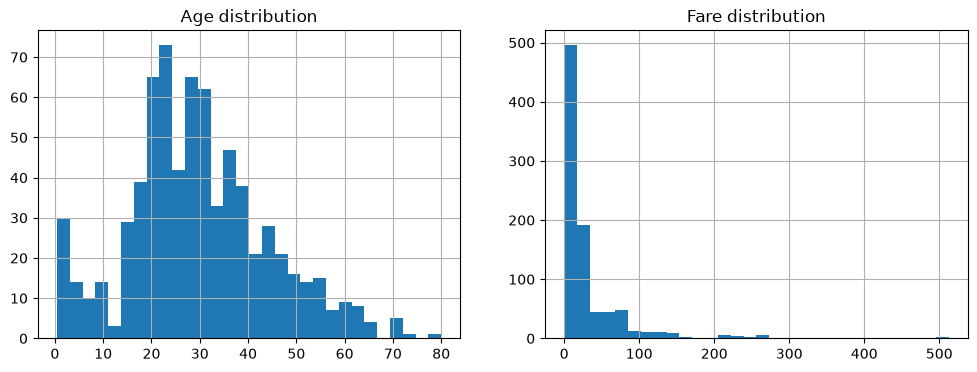

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['Age'].hist(bins=30, ax=axes[0])
axes[0].set_title('Age distribution')
df['Fare'].hist(bins=30, ax=axes[1])
axes[1].set_title('Fare distribution')
plt.show()

In [10]:
df.isnull().mean().sort_values(ascending=False)

Cabin          0.771044
Age            0.198653
Embarked       0.002245
PassengerId    0.000000
Name           0.000000
Pclass         0.000000
Survived       0.000000
Sex            0.000000
Parch          0.000000
SibSp          0.000000
Fare           0.000000
Ticket         0.000000
dtype: float64

In [11]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [12]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df.groupby(['Pclass','Sex'])['Age'].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [14]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.8 KB


In [16]:
df['Age'].isnull().sum()

np.int64(0)

In [17]:
df['Has Cabin'] = df['Cabin'].notna().astype(int)

In [18]:
df.groupby('Has Cabin')['Survived'].mean()

Has Cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

In [19]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Has Cabin        0
dtype: int64

In [20]:
df['Titles'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Titles'].value_counts()

Titles
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [21]:
df.groupby('Titles')['Survived'].mean()

Titles
Capt        0.000000
Col         0.500000
Countess    1.000000
Don         0.000000
Dr          0.428571
Jonkheer    0.000000
Lady        1.000000
Major       0.500000
Master      0.575000
Miss        0.697802
Mlle        1.000000
Mme         1.000000
Mr          0.156673
Mrs         0.792000
Ms          1.000000
Rev         0.000000
Sir         1.000000
Name: Survived, dtype: float64

In [22]:
df['Family Size'] = df['SibSp'] + df['Parch'] + 1

In [23]:
df.groupby('Family Size')['Survived'].mean()

Family Size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [24]:
df['IsAlone'] = (df['Family Size'] == 1).astype(int)
df.groupby('IsAlone')['Survived'].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

In [25]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [26]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [27]:
df = pd.get_dummies(df, columns=['Titles'], drop_first=True)

In [28]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [29]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has Cabin,Family Size,IsAlone,...,Titles_Major,Titles_Master,Titles_Miss,Titles_Mlle,Titles_Mme,Titles_Mr,Titles_Mrs,Titles_Ms,Titles_Rev,Titles_Sir
0,0,3,0,22.0,1,0,7.2500,0,2,0,...,False,False,False,False,False,True,False,False,False,False
1,1,1,1,38.0,1,0,71.2833,1,2,0,...,False,False,False,False,False,False,True,False,False,False
2,1,3,1,26.0,0,0,7.9250,0,1,1,...,False,False,True,False,False,False,False,False,False,False
3,1,1,1,35.0,1,0,53.1000,1,2,0,...,False,False,False,False,False,False,True,False,False,False
4,0,3,0,35.0,0,0,8.0500,0,1,1,...,False,False,False,False,False,True,False,False,False,False


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Sex              891 non-null    int64  
 3   Age              891 non-null    float64
 4   SibSp            891 non-null    int64  
 5   Parch            891 non-null    int64  
 6   Fare             891 non-null    float64
 7   Has Cabin        891 non-null    int64  
 8   Family Size      891 non-null    int64  
 9   IsAlone          891 non-null    int64  
 10  Embarked_Q       891 non-null    bool   
 11  Embarked_S       891 non-null    bool   
 12  Titles_Col       891 non-null    bool   
 13  Titles_Countess  891 non-null    bool   
 14  Titles_Don       891 non-null    bool   
 15  Titles_Dr        891 non-null    bool   
 16  Titles_Jonkheer  891 non-null    bool   
 17  Titles_Lady      891 non-nu

In [31]:
df.shape

(891, 28)

In [32]:
X = df.drop('Survived', axis = 1)
y = df['Survived']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nColumns being used as features:\n{list(X.columns)}")

Features shape: (891, 27)
Target shape: (891,)

Columns being used as features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Has Cabin', 'Family Size', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Titles_Col', 'Titles_Countess', 'Titles_Don', 'Titles_Dr', 'Titles_Jonkheer', 'Titles_Lady', 'Titles_Major', 'Titles_Master', 'Titles_Miss', 'Titles_Mlle', 'Titles_Mme', 'Titles_Mr', 'Titles_Mrs', 'Titles_Ms', 'Titles_Rev', 'Titles_Sir']


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 712 samples
Test set: 179 samples


In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [36]:
# Define models in a dictionary — clean way to loop through them
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}


In [38]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model
    }
    print(f"{name:25s} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

Logistic Regression       | Train: 0.8343 | Test: 0.8268
Decision Tree             | Train: 0.9846 | Test: 0.7933
Random Forest             | Train: 0.9846 | Test: 0.8324
SVM                       | Train: 0.8497 | Test: 0.8101
KNN                       | Train: 0.8680 | Test: 0.8101


In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_model = results[best_name]['model']
print(f"Best Model: {best_model}")

y_pred = best_model.predict(X_test_scaled)

Best Model: RandomForestClassifier(random_state=42)


In [41]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])

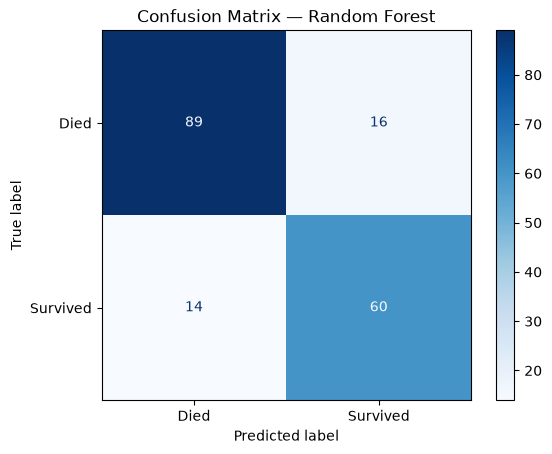

In [42]:
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))


              precision    recall  f1-score   support

        Died       0.86      0.85      0.86       105
    Survived       0.79      0.81      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



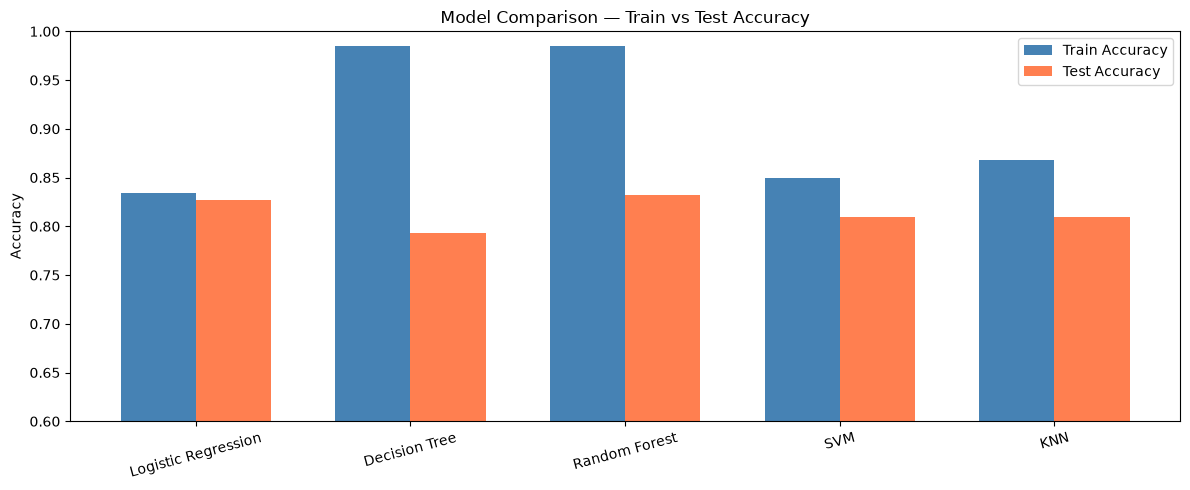

In [44]:
model_names = list(results.keys())
train_accs = [results[n]['train_acc'] for n in model_names]
test_accs = [results[n]['test_acc'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue')
ax.bar(x + width/2, test_accs, width, label='Test Accuracy', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Train vs Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()
ax.set_ylim(0.6, 1.0)
plt.tight_layout()
plt.show()


In [45]:
from sklearn.model_selection import cross_val_score

print("Cross-Validation Scores (5-fold):\n")
for name, model_info in results.items():
    # Need to re-instantiate models for clean CV
    model = models[name]
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    print(f"{name:25s} | Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f} | Scores: {cv_scores.round(4)}")


Cross-Validation Scores (5-fold):

Logistic Regression       | Mean: 0.8258 | Std: 0.0152 | Scores: [0.8322 0.8322 0.831  0.7958 0.838 ]
Decision Tree             | Mean: 0.7627 | Std: 0.0259 | Scores: [0.7622 0.7483 0.8028 0.7254 0.7746]
Random Forest             | Mean: 0.8076 | Std: 0.0181 | Scores: [0.8182 0.7972 0.7958 0.7887 0.838 ]
SVM                       | Mean: 0.8342 | Std: 0.0148 | Scores: [0.8462 0.8462 0.8239 0.8099 0.8451]
KNN                       | Mean: 0.8216 | Std: 0.0174 | Scores: [0.8531 0.8252 0.8099 0.8169 0.8028]


In [46]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,        # use all CPU cores
    verbose=1         # show progress
)

rf_grid.fit(X_train_scaled, y_train)

print(f"\nBest RF Parameters: {rf_grid.best_params_}")
print(f"Best RF CV Score:   {rf_grid.best_score_:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best RF Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RF CV Score:   0.8413


In [47]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear'],
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print(f"\nBest SVM Parameters: {svm_grid.best_params_}")
print(f"Best SVM CV Score:   {svm_grid.best_score_:.4f}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best SVM Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV Score:   0.8342


In [48]:
# Get the best models (already refit on full training data by GridSearchCV)
best_rf = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_

# Evaluate on the held-out test set
rf_test_acc = best_rf.score(X_test_scaled, y_test)
svm_test_acc = best_svm.score(X_test_scaled, y_test)

print("=== Final Test Set Results (Tuned Models) ===")
print(f"Random Forest:  {rf_test_acc:.4f}")
print(f"SVM:            {svm_test_acc:.4f}")


=== Final Test Set Results (Tuned Models) ===
Random Forest:  0.8212
SVM:            0.8101


Final Model: Random Forest
Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

              precision    recall  f1-score   support

        Died       0.83      0.87      0.85       105
    Survived       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



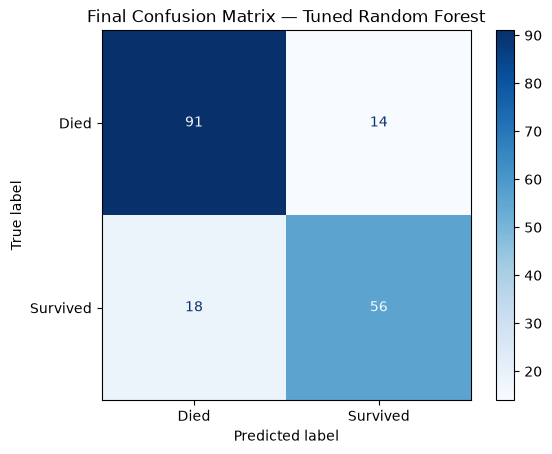

In [49]:
# Pick the best overall
if rf_test_acc >= svm_test_acc:
    final_model = best_rf
    final_name = "Random Forest"
else:
    final_model = best_svm
    final_name = "SVM"

y_final_pred = final_model.predict(X_test_scaled)

print(f"Final Model: {final_name}")
print(f"Best Params: {rf_grid.best_params_ if final_name == 'Random Forest' else svm_grid.best_params_}")
print()
print(classification_report(y_test, y_final_pred, target_names=['Died', 'Survived']))

# Final confusion matrix
cm = confusion_matrix(y_test, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title(f'Final Confusion Matrix — Tuned {final_name}')
plt.show()


In [50]:
import joblib

joblib.dump(final_model, 'titanic_model.pkl')
joblib.dump(scaler, 'titanic_scaler.pkl')
print(f"Model saved as titanic_model.pkl")
print(f"Scaler saved as titanic_scaler.pkl")


Model saved as titanic_model.pkl
Scaler saved as titanic_scaler.pkl
